### 13.

In [37]:
import pandas as pd
data = pd.read_excel('data/hr_employee_data.xlsx')

print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp_Id                 14999 non-null  str    
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  int64  
 4   average_montly_hours   14999 non-null  int64  
 5   time_spend_company     14999 non-null  int64  
 6   Work_accident          14999 non-null  int64  
 7   left                   14999 non-null  int64  
 8   promotion_last_5years  14999 non-null  int64  
 9   Department             14999 non-null  str    
 10  salary                 14999 non-null  str    
dtypes: float64(2), int64(6), str(3)
memory usage: 1.3 MB
None


In [38]:
print(data.head())

     Emp_Id  satisfaction_level  last_evaluation  number_project  \
0  IND02438                0.38             0.53               2   
1  IND28133                0.80             0.86               5   
2  IND07164                0.11             0.88               7   
3  IND30478                0.72             0.87               5   
4  IND24003                0.37             0.52               2   

   average_montly_hours  time_spend_company  Work_accident  left  \
0                   157                   3              0     1   
1                   262                   6              0     1   
2                   272                   4              0     1   
3                   223                   5              0     1   
4                   159                   3              0     1   

   promotion_last_5years Department  salary  
0                      0      sales     low  
1                      0      sales  medium  
2                      0      sales  medium 

### Visualiseringar för explorativ analys (HR-data)

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Colorblind-safe, fixed palette: index 0 = stayed, index 1 = left
palette_binary = sns.color_palette("colorblind")[:2]
left_labels = ["Stayed", "Left"]

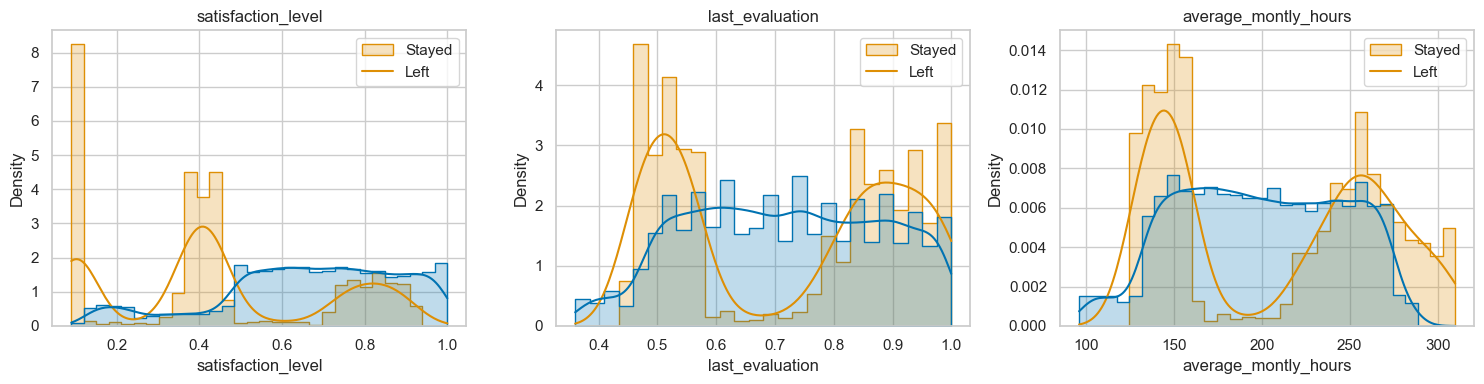

In [40]:
# Distributions of key numeric features, split by attrition (left)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["satisfaction_level", "last_evaluation", "average_montly_hours"]):
    sns.histplot(
        data=data, x=col, hue="left", palette=palette_binary,
        element="step", stat="density", common_norm=False, kde=True, ax=ax,
    )
    ax.set_title(col)
    ax.legend(title="", labels=left_labels)
plt.tight_layout()
plt.show()

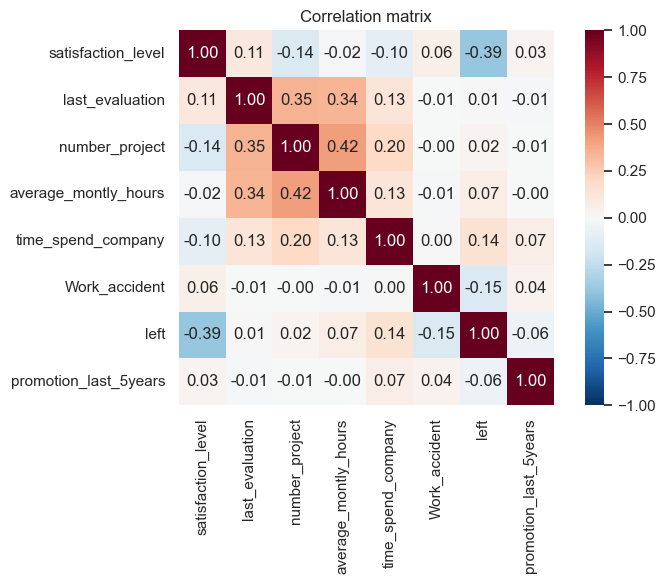

In [41]:
# Correlation matrix of numeric features (diverging scale, centered on 0)
numeric_cols = [
    "satisfaction_level", "last_evaluation", "number_project",
    "average_montly_hours", "time_spend_company", "Work_accident",
    "left", "promotion_last_5years",
]
corr = data[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

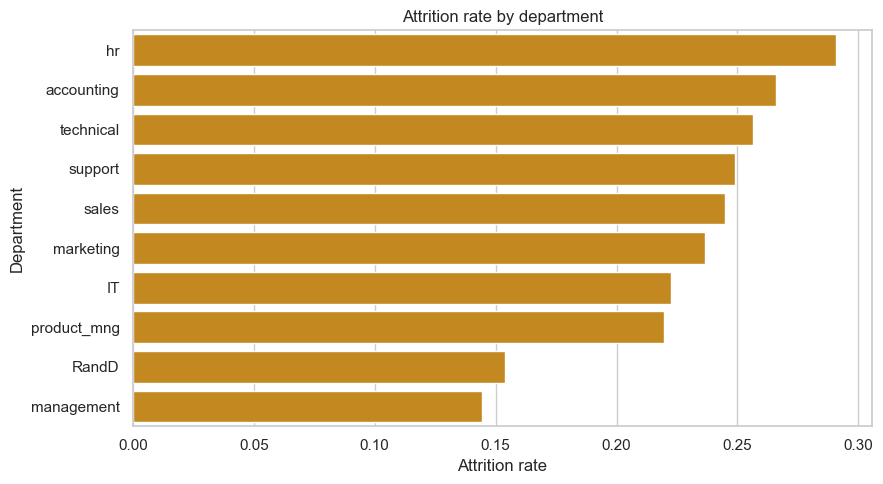

In [42]:
# Attrition rate by department
dept_rate = data.groupby("Department")["left"].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=dept_rate.values, y=dept_rate.index, color=palette_binary[1])
plt.xlabel("Attrition rate")
plt.ylabel("Department")
plt.title("Attrition rate by department")
plt.tight_layout()
plt.show()

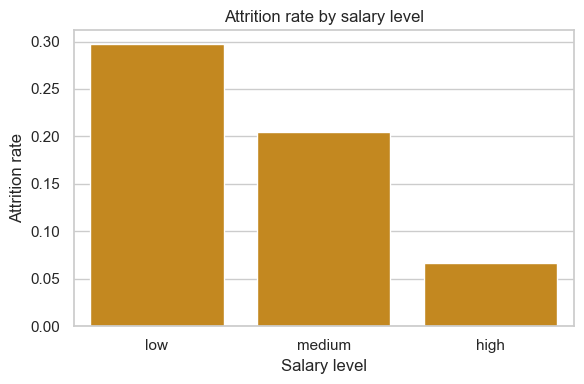

In [43]:
# Attrition rate by salary level
salary_order = ["low", "medium", "high"]
salary_rate = data.groupby("salary")["left"].mean().reindex(salary_order)

plt.figure(figsize=(6, 4))
sns.barplot(x=salary_rate.index, y=salary_rate.values, order=salary_order, color=palette_binary[1])
plt.ylabel("Attrition rate")
plt.xlabel("Salary level")
plt.title("Attrition rate by salary level")
plt.tight_layout()
plt.show()

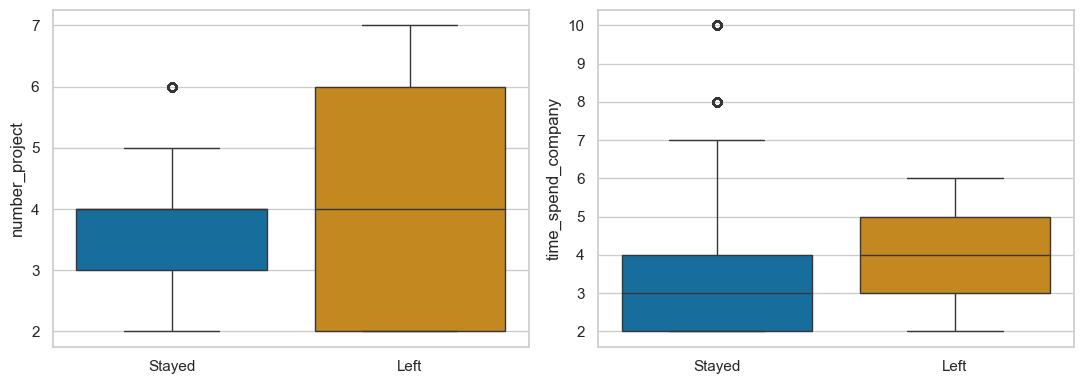

In [44]:
# Workload comparison: number of projects & tenure, by attrition
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["number_project", "time_spend_company"]):
    sns.boxplot(data=data, x="left", y=col, hue="left", palette=palette_binary, legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(left_labels)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

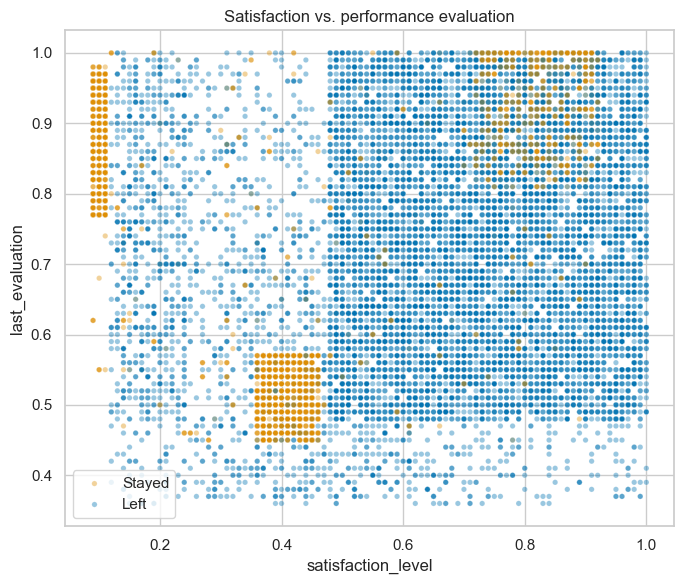

In [45]:
# Satisfaction vs. performance evaluation, colored by attrition
plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=data, x="satisfaction_level", y="last_evaluation",
    hue="left", palette=palette_binary, alpha=0.4, s=15,
)
plt.title("Satisfaction vs. performance evaluation")
plt.legend(title="", labels=left_labels)
plt.tight_layout()
plt.show()

### 16.

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import linear_model

from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error

In [47]:
diamonds_eda = pd.read_csv("data/diamonds.csv")

print(diamonds_eda.info())
print(diamonds_eda.head())

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 4.5 MB
None
   Unnamed: 0  carat      cut color clarity  depth  table  price     x     y  \
0           1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1           2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2           3   0.23     Good     E     VS1   56.9   65.0    327  

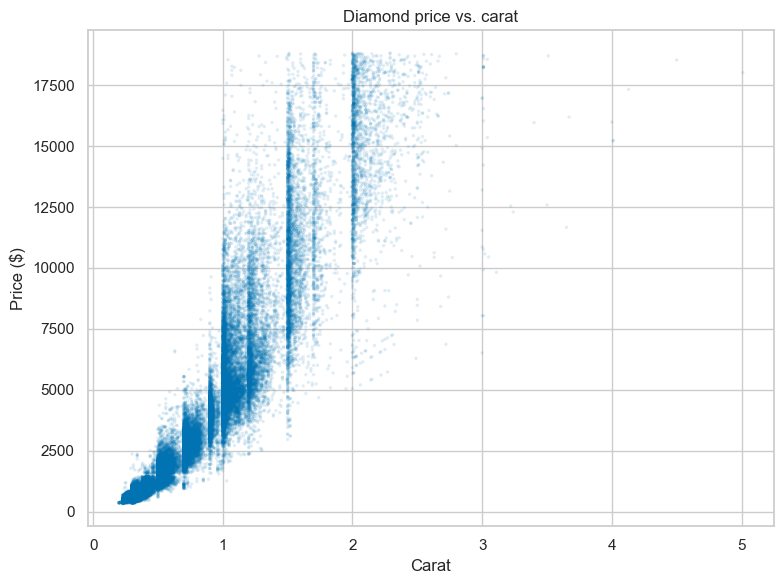

In [48]:
# Diamond price vs. carat
plt.figure(figsize=(8, 6))
plt.scatter(diamonds_eda["carat"], diamonds_eda["price"], s=6, alpha=0.12, color="#0173B2", edgecolors="none")
plt.xlabel("Carat")
plt.ylabel("Price ($)")
plt.title("Diamond price vs. carat")
plt.tight_layout()
plt.show()

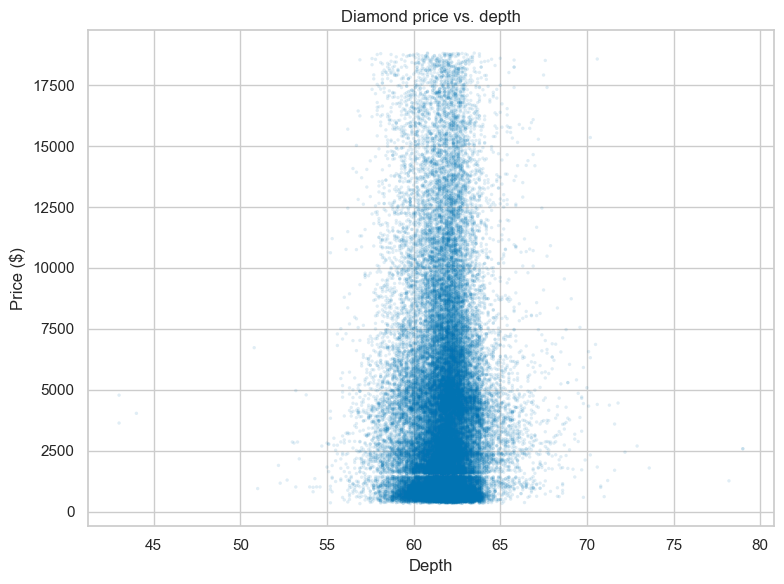

In [49]:
# Diamond price vs. depth
plt.figure(figsize=(8, 6))
plt.scatter(diamonds_eda["depth"], diamonds_eda["price"], s=6, alpha=0.12, color="#0173B2", edgecolors="none")
plt.xlabel("Depth")
plt.ylabel("Price ($)")
plt.title("Diamond price vs. depth")
plt.tight_layout()
plt.show()

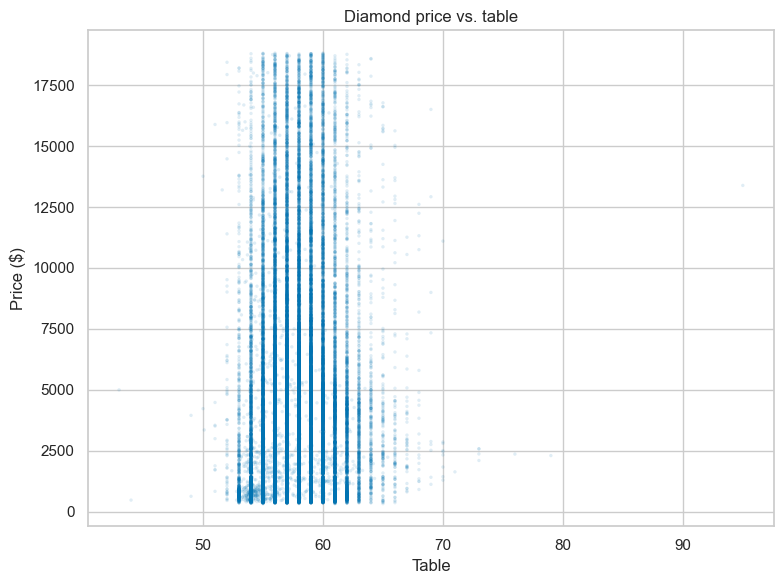

In [50]:
# Diamond price vs. table
plt.figure(figsize=(8, 6))
plt.scatter(diamonds_eda["table"], diamonds_eda["price"], s=6, alpha=0.12, color="#0173B2", edgecolors="none")
plt.xlabel("Table")
plt.ylabel("Price ($)")
plt.title("Diamond price vs. table")
plt.tight_layout()
plt.show()

### Modelling pipeline: OneHotEncoder inside ColumnTransformer + Pipeline

In [51]:
# Features & train/test split (working from the original, unencoded diamonds_eda)
categorical_cols = ["cut", "color", "clarity"]
numeric_cols = ["carat", "depth", "table", "x", "y", "z"]
feature_cols = numeric_cols + categorical_cols

X = diamonds_eda[feature_cols]
y = diamonds_eda["price"]

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=36)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (32364, 9)
Validation size: (10788, 9)
Test size: (10788, 9)


In [52]:
# Preprocessor: one-hot encode the categorical columns, pass numeric columns through unchanged.
# handle_unknown="ignore" so a category seen only in the test split doesn't crash the encoder.
preprocessor = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)],
    remainder="passthrough",
)

In [53]:
# Baseline model: Linear Regression
linreg_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", LinearRegression()),
])
linreg_pipeline.fit(X_train, y_train)

y_pred_linreg = linreg_pipeline.predict(X_val)
mae_linreg = mean_absolute_error(y_val, y_pred_linreg)
rmse_linreg = mean_squared_error(y_val, y_pred_linreg) ** 0.5

print(f"Linear Regression - MAE: {mae_linreg:.2f}, RMSE: {rmse_linreg:.2f}")

Linear Regression - MAE: 736.87, RMSE: 1105.93


In [54]:
# Lasso
lasso_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", linear_model.Lasso(alpha=0.1, max_iter=10000)),
])
lasso_pipeline.fit(X_train, y_train)
lasso_pred = lasso_pipeline.predict(X_val)

In [55]:
# Decision Tree, tuned via GridSearchCV over max_depth (5-fold CV, scored on MAE)
tree_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=42)),
])

param_grid = {"regressor__max_depth": [4, 6, 8, 10, 20, None]}

grid_search = GridSearchCV(tree_pipeline, param_grid, cv=5, scoring="neg_mean_absolute_error")
grid_search.fit(X_train, y_train)
print("Best params:", grid_search.best_params_)

best_tree = grid_search.best_estimator_
y_pred_tree = best_tree.predict(X_val)
mae_tree = mean_absolute_error(y_val, y_pred_tree)
rmse_tree = mean_squared_error(y_val, y_pred_tree) ** 0.5

print(f"Decision Tree - MAE: {mae_tree:.2f}, RMSE: {rmse_tree:.2f}")

Best params: {'regressor__max_depth': 20}
Decision Tree - MAE: 362.64, RMSE: 758.49


In [56]:
# Random forest
rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

hyperparams = {
    "regressor__max_depth": [3, 5, 7, None],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4]
}

rf_reg_gs = GridSearchCV(rf_pipeline, hyperparams, cv=5, n_jobs=-1)
rf_reg_gs.fit(X_train, y_train)

rf_reg_gs_pred = rf_reg_gs.predict(X_val)

best_forest = rf_reg_gs.best_estimator_
y_pred_forest = best_forest.predict(X_val)
mae_forest = mean_absolute_error(y_val, y_pred_forest)
rmse_forest = mean_squared_error(y_val, y_pred_forest) ** 0.5

print(f"Random Forest - MAE: {mae_forest:.2f}, RMSE: {rmse_forest:.2f}")

Random Forest - MAE: 274.86, RMSE: 553.27


In [57]:
lr_rmse = root_mean_squared_error(y_pred_linreg, y_val)
lasso_rmse = root_mean_squared_error(lasso_pred, y_val)
tree_rmse = root_mean_squared_error(y_pred_tree, y_val)
rf_rmse = root_mean_squared_error(y_pred_forest, y_val)

print("RMSE LR:", lr_rmse, "\nRMSE Lasso:", lasso_rmse, "\nRMSE Tree:", tree_rmse, "\nRMSE RF:", rf_rmse)

RMSE LR: 1105.934781449161 
RMSE Lasso: 1105.9422482679493 
RMSE Tree: 758.4896541019068 
RMSE RF: 553.2746494085635


## Testar modellen på testdatan

In [58]:
best_model = rf_reg_gs.best_estimator_.fit(X_train_full, y_train_full)

In [59]:
best_test_pred = best_model.predict(X_test)

best_rmse_test = root_mean_squared_error(best_test_pred, y_test)
print(best_rmse_test)

555.9098200591397


## Tränar modellen på hela datasetet och sparar modellen

In [60]:
final_model = rf_reg_gs.best_estimator_.fit(X, y)

In [61]:
import joblib

joblib.dump(final_model, 'RF_finished.pkl')
print("Model saved!")
loaded_model = joblib.load('RF_finished.pkl')
print("Model loaded!")

Model saved!
Model loaded!
